# agentic-data-analyst: a quick tour

A short, runnable tour of what this library does: turn a question into a
catalog-grounded, typed analysis, enriched with dbt metadata, and executed on
real PySpark. Every object below is the production code under `src/`,
including the LLM: this notebook calls a real model through
`OpenRouterClient`, the same class `agentic_data_analyst.bootstrap` wires up
for the API.

**Requires `OPENROUTER_API_KEY`** in a `.env` file at the repo root (see the
main [README](../README.md#quick-start)) and makes real network calls. Because
it's a live model, the exact plan, wording, and even which valid IR it builds
can vary between runs — this is a real, unscripted call, not a fixture. The
guardrails hold regardless: an invalid IR is rejected (§ 4 shows this
happening), never silently coerced into something executable.


In [1]:
from pathlib import Path

from IPython.display import Image, Markdown, display

from agentic_data_analyst.config import Settings
from agentic_data_analyst.data.generator import generate
from agentic_data_analyst.llm.openrouter import OpenRouterClient

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
DATA_DIR = REPO_ROOT / "data" / "sample"
DBT_PROJECT_DIR = REPO_ROOT / "examples" / "dbt" / "gaming_analytics" / "target"
ASSETS_DIR = REPO_ROOT / "docs" / "assets" / "agentic-workflow"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

if not (DATA_DIR / "players.parquet").exists():
    generate(DATA_DIR)

settings = Settings.from_env(env_file=REPO_ROOT / ".env")
if settings.openrouter_api_key is None:
    raise RuntimeError("Set OPENROUTER_API_KEY in .env to run this notebook (see README Quick start).")

llm = OpenRouterClient(
    api_key=settings.openrouter_api_key.get_secret_value(),
    model=settings.openrouter_model,
    base_url=str(settings.openrouter_base_url),
    timeout_seconds=settings.llm_timeout_seconds,
    max_response_bytes=settings.max_llm_response_bytes,
)
print("model:", settings.openrouter_model)


def show_chart(fig, filename: str, title: str) -> None:
    """Save the committed, GitHub-safe PNG and display it (not the interactive
    widget) so the notebook renders the same way on GitHub as it does here."""
    fig.update_layout(title=title, template="plotly_white", font=dict(size=13), margin=dict(t=60, l=60, r=30, b=50))
    path = ASSETS_DIR / filename
    fig.write_image(str(path), scale=2)
    display(Image(filename=str(path)))


def table(headers: list[str], rows: list[list]) -> Markdown:
    head = "| " + " | ".join(headers) + " |\n| " + " | ".join(["---"] * len(headers)) + " |"
    body = "\n".join("| " + " | ".join(str(v) for v in row) + " |" for row in rows)
    return Markdown(head + "\n" + body)

model: openai/gpt-4.1


## 1. Catalog: what data is there?

`LocalParquetCatalog` discovers `*.parquet` files and their `.metadata.json`
sidecars — no dbt required for this part.


In [2]:
from agentic_data_analyst.catalog.local import LocalParquetCatalog

catalog = LocalParquetCatalog(DATA_DIR)
table(["dataset", "description"], [[c.name, c.description] for c in catalog.list_datasets()])

| dataset | description |
| --- | --- |
| events | Product telemetry events emitted during player sessions. |
| matches | Completed multiplayer matches and player outcomes. |
| players | Player account, acquisition, geography, and behavioral segment attributes. |
| purchases | Successful in-game purchases with product and revenue attributes. |
| sessions | Player login sessions with duration and device context. |

## 2. Enrich it with dbt metadata

`DbtArtifactLoader` reads a dbt project's compiled `manifest.json` /
`catalog.json` (no dbt-core, no running dbt process) and
`DbtEnrichedCatalog` attaches descriptions, lineage, and declared tests to
the matching physical dataset. The example project
(`examples/dbt/gaming_analytics/`) documents `players` and `sessions` as dbt
staging models, and defines a downstream `mart_player_retention` model that
is *not* materialized as Parquet — it exists only to enrich discovery, and
can never itself be selected or executed.


In [3]:
from agentic_data_analyst.dbt import DbtArtifactLoader, DbtEnrichedCatalog

dbt_project = DbtArtifactLoader(DBT_PROJECT_DIR).load()
catalog = DbtEnrichedCatalog(catalog, dbt_project)

players = catalog.get_dataset("players")
print("relation:", players.relation)
print("lineage:", players.lineage)
print("declared tests:", [(t.test_type, t.columns) for t in players.quality_expectations])

relation: database='analytics' schema_name='staging' identifier='players'
lineage: upstream=('source:raw_players',) downstream=('model:fct_player_sessions',)
declared tests: [('accepted_values', ('segment',)), ('not_null', ('player_id',)), ('unique', ('player_id',))]


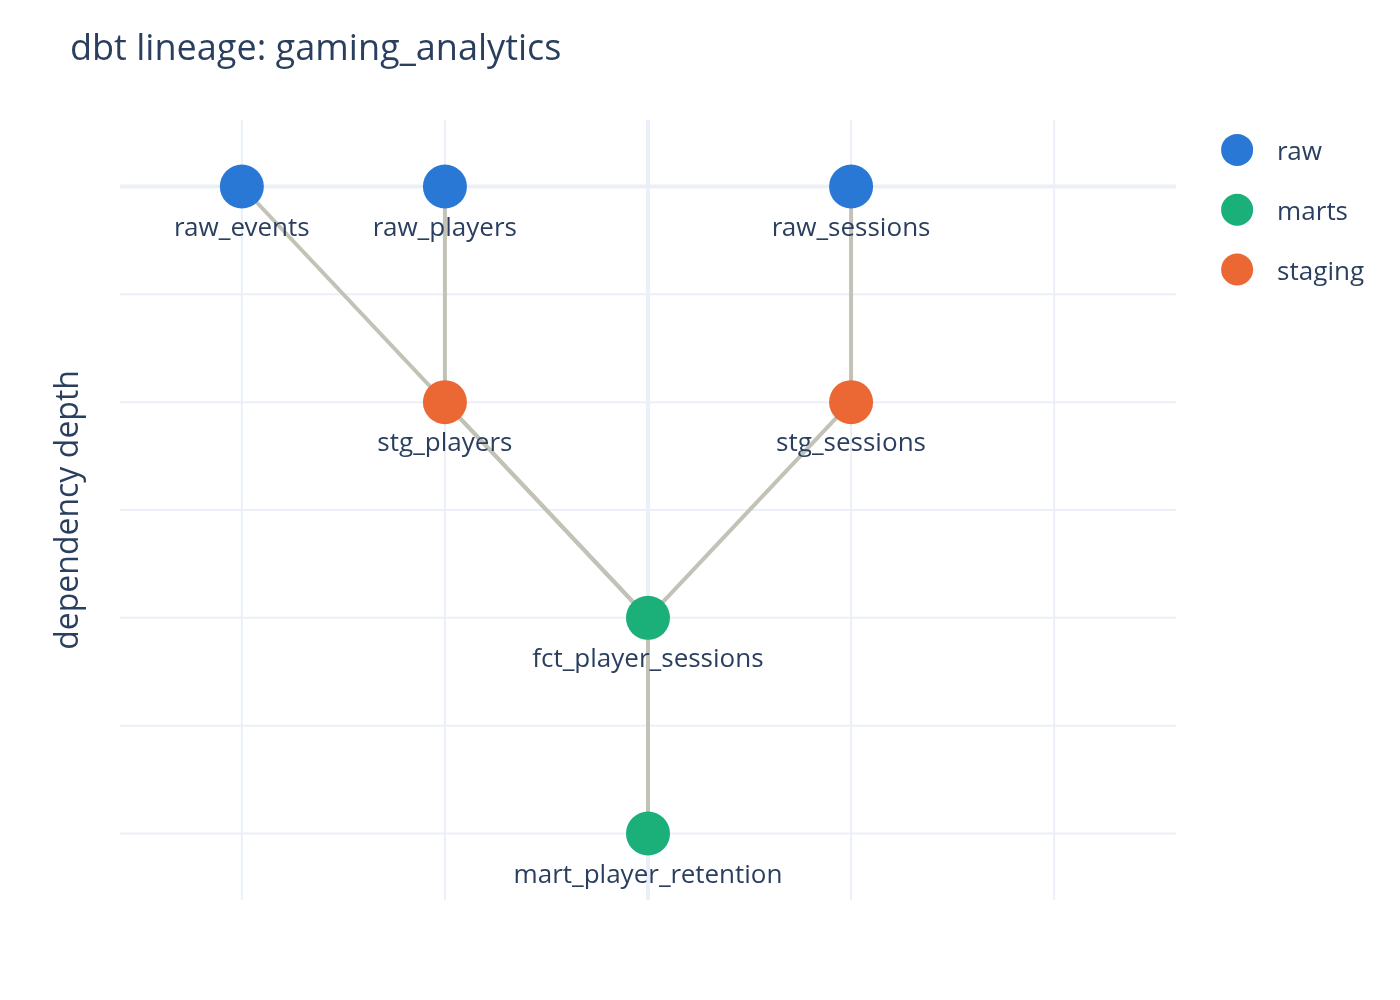

In [4]:
import plotly.graph_objects as go

# A small, fixed layout for this project's seven relations — good enough for a demo graph.
POSITION = {
    "raw_players": (-1, 0),
    "raw_sessions": (1, 0),
    "raw_events": (-2, 0),
    "stg_players": (-1, 1),
    "stg_sessions": (1, 1),
    "fct_player_sessions": (0, 2),
    "mart_player_retention": (0, 3),
}
COLOR = {"raw": "#2a78d6", "staging": "#eb6834", "marts": "#1baf7a"}

fig = go.Figure()
for target in dbt_project.relations.values():
    for source_id in target.depends_on:
        source = dbt_project.relations.get(source_id)
        if source:
            x0, y0 = POSITION[source.name]
            x1, y1 = POSITION[target.name]
            fig.add_trace(
                go.Scatter(
                    x=[x0, x1], y=[y0, y1], mode="lines", line=dict(color="#c3c2b7"), showlegend=False, hoverinfo="skip"
                )
            )

seen = set()
for relation in dbt_project.relations.values():
    x, y = POSITION[relation.name]
    category = relation.schema_name or "raw"
    fig.add_trace(
        go.Scatter(
            x=[x],
            y=[y],
            mode="markers+text",
            text=[relation.name],
            textposition="bottom center",
            marker=dict(size=22, color=COLOR.get(category, "gray")),
            name=category,
            legendgroup=category,
            showlegend=category not in seen,
        )
    )
    seen.add(category)

fig.update_yaxes(autorange="reversed", showticklabels=False, title="dependency depth")
fig.update_xaxes(showticklabels=False, range=[-2.6, 2.6])
show_chart(fig, "dbt-lineage.png", "dbt lineage: gaming_analytics")

## 3. Ask the model a question

From here on every call goes to the real model configured in `.env`
(`OPENROUTER_MODEL`, default `openai/gpt-4.1`) through the same
`MetadataDiscoveryAgent` / `PlanningAgent` / `GenerationAgent` /
`InterpretationAgent` classes the API uses. Discovery only sees the compact,
dbt-enriched search results below — full schemas are loaded only for
whatever it selects.


In [5]:
from agentic_data_analyst.agents import GenerationAgent, InterpretationAgent, MetadataDiscoveryAgent, PlanningAgent
from agentic_data_analyst.models import AnalyticsQuestion

question = AnalyticsQuestion(question="What is average session duration by player segment?")

candidates = catalog.search(question.question, limit=5)
selection = await MetadataDiscoveryAgent(llm, max_attempts=settings.llm_max_attempts).select(question, candidates)
print("selected:", selection.datasets)
print("rationale:", selection.rationale)

selected: ('sessions', 'players')
rationale: To calculate average session duration by player segment, we need session duration data (from the 'sessions' dataset) and player segment information (from the 'players' dataset). The other datasets do not provide relevant session or segmentation data.


In [6]:
metadata = tuple(catalog.get_dataset(name) for name in selection.datasets)
plan = await PlanningAgent(llm, max_attempts=settings.llm_max_attempts).plan(question, metadata)
print(plan.objective)
for step in plan.steps:
    print(" -", step)

Calculate the average session duration for each player segment.
 - Join sessions (s) to players (p) on player_id.
 - Group the joined data by p.segment.
 - Calculate the average of s.duration_minutes for each segment.


## 4. Validate and execute

`spark_dataframe_ir/v1` is a closed relational graph with no node for
imports, file paths, shell commands, or raw SQL (see
[`SECURITY.md`](../SECURITY.md)). `GenerationAgent` only checks that the
model reused the planned datasets/columns; `AnalysisValidator` then
re-resolves everything against the catalog, checks column and expression
types, and enforces the policy limits. A live model can produce an IR that
fails that second check (an aggregate over the wrong type, for example) —
when it does, this is a rejection, not a retry-until-it-passes loop, exactly
as production behaves; we just ask the model for a fresh attempt from
scratch rather than failing the whole notebook on one bad draw.


In [7]:
from agentic_data_analyst.execution import SparkAnalysisRunner, SparkCompiler, SparkSessionFactory
from agentic_data_analyst.guardrails import AnalysisValidator

validator = AnalysisValidator(catalog, approved_data_root=DATA_DIR, policy=settings.analysis_policy)
generator = GenerationAgent(llm, max_attempts=settings.llm_max_attempts)

for attempt in range(3):
    ir = await generator.generate(question, plan, metadata, max_result_rows=settings.max_result_rows)
    outcome = validator.authorize(ir)
    if outcome.result.is_valid:
        break
    print(f"attempt {attempt + 1} rejected: {[issue.code for issue in outcome.result.issues]}")
else:
    raise RuntimeError("The model could not produce a valid analysis in 3 attempts; see the rejections above.")

print(f"IR: {len(ir.steps)} steps -> {[type(s).__name__ for s in ir.steps]}")
print(SparkCompiler().render(outcome.analysis))

IR: 3 steps -> ['JoinStep', 'AggregateStep', 'LimitStep']
# Generated from validated spark_dataframe_ir/v1
from pyspark.sql import functions as F
s = spark.read.parquet(catalog.get_dataset("sessions").path).select(F.col("player_id").alias("s__player_id"), F.col("duration_minutes").alias("s__duration_minutes"))
p = spark.read.parquet(catalog.get_dataset("players").path).select(F.col("player_id").alias("p__player_id"), F.col("segment").alias("p__segment"))
joined = s.join(p, (F.col("s__player_id") == F.col("p__player_id")), "inner")
agg = joined.groupBy(F.col("p__segment").alias("segment")).agg(F.avg(F.col("s__duration_minutes")).alias("avg_session_duration_minutes"))
result = agg.limit(100)
result = result


In [8]:
session_factory = SparkSessionFactory(app_name="agentic-analytics-workflow-notebook")
runner = SparkAnalysisRunner(validator=validator, compiler=SparkCompiler(), session_factory=session_factory)
result = runner.execute(ir)
table(result.columns, [[row[c] for c in result.columns] for row in result.rows])

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/22 01:26:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


| segment | avg_session_duration_minutes |
| --- | --- |
| core | 31.372236958443874 |
| competitive | 31.719621342512912 |
| casual | 16.858300132802125 |

## 5. Result

The chart plots whatever the model's plan actually produced: the first
result column as the category axis, the second as the value.


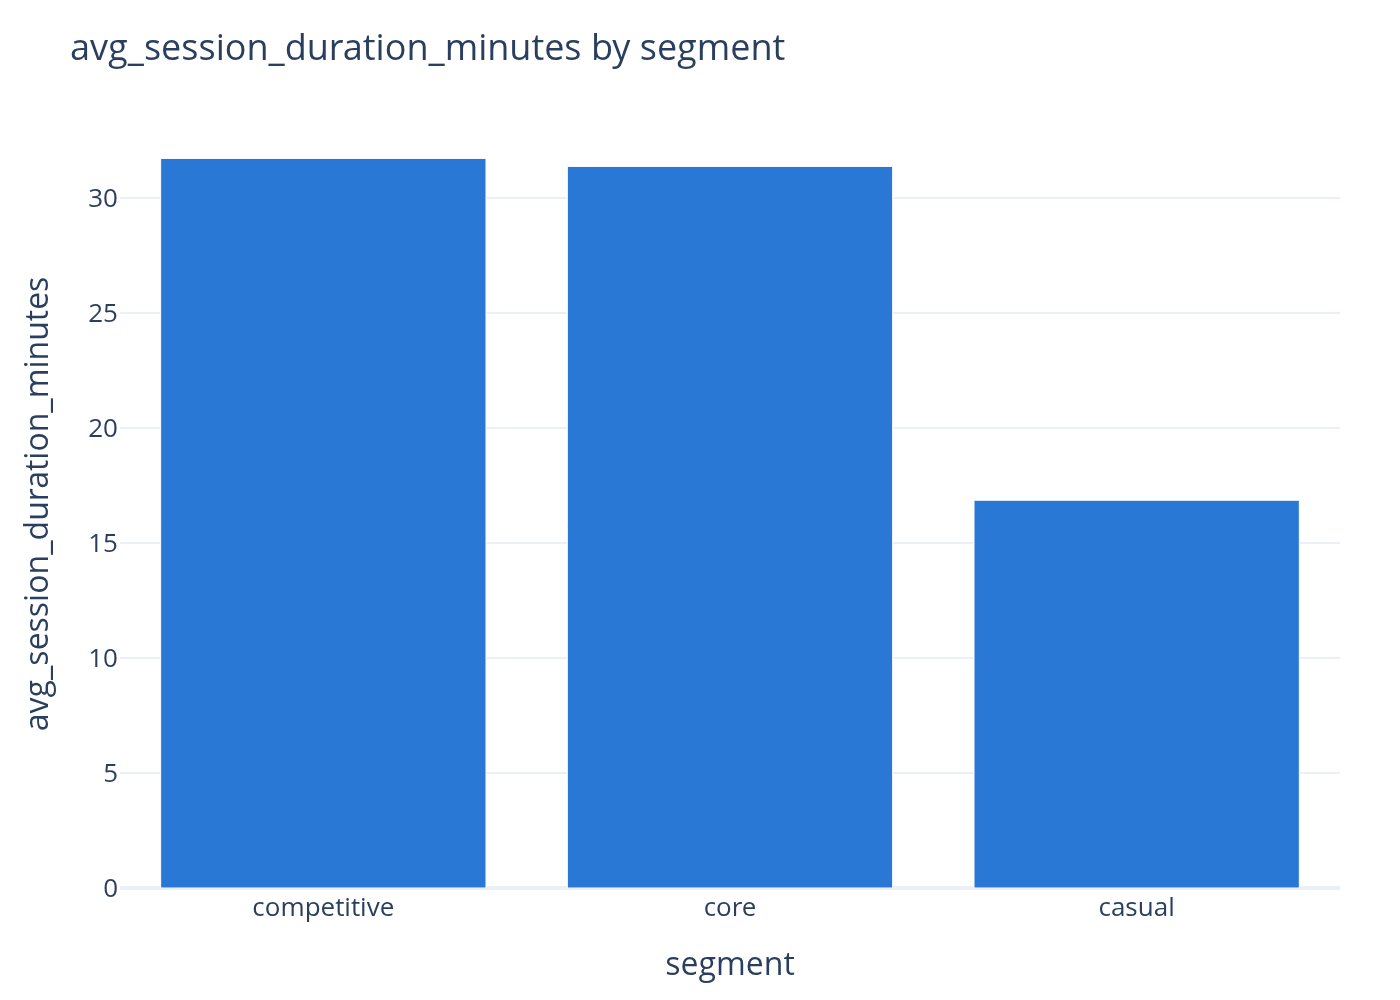

In [9]:
category_col, value_col = result.columns[0], result.columns[1]
rows = sorted(result.rows, key=lambda r: -(r[value_col] or 0))
fig = go.Figure(
    go.Bar(
        x=[r[category_col] for r in rows],
        y=[r[value_col] for r in rows],
        marker_color="#2a78d6",
    )
)
fig.update_xaxes(title=category_col)
fig.update_yaxes(title=value_col)
show_chart(fig, "session-duration-by-segment.png", f"{value_col} by {category_col}")

In [10]:
explanation = await InterpretationAgent(llm, max_attempts=settings.llm_max_attempts).explain(question, plan, result)
display(Markdown(f"> {explanation}"))

> The returned rows show the average session duration, in minutes, for each player segment. Core players have an average session duration of approximately 31.37 minutes, competitive players average about 31.72 minutes, and casual players average about 16.86 minutes.

That explanation is also a real model call over the result rows, not scripted.

**Guardrails, briefly:** nothing above ever asked the model for code and ran
it — every stage exchanged a strictly-validated Pydantic object, and dbt's
metadata is descriptive only (a mart with no physical dataset, like
`mart_player_retention`, can never be selected or executed). See
[`SECURITY.md`](../SECURITY.md) and `tests/unit/test_prompt_injection.py` for
what that actually stops.


In [11]:
# Release the shared local Spark session so this notebook exits cleanly.
runner.close()

---

Regenerate this notebook's outputs and PNGs with `make notebooks` (requires
`OPENROUTER_API_KEY`).
